# Guía práctica 1

## Ejercicio 4 (b)

In [21]:
from matplotlib.pyplot import (
    figure,
    grid,
    legend,
    plot,
    show,
    stem,
    step,
    title,
    xlabel,
    ylabel,
    ylim,
)
from numpy import (
    angle,
    arange,
    ceil,
    convolve,
    cos,
    ones,
    pi,
    unwrap,
    zeros,
)
from scipy.signal import freqz, lfilter

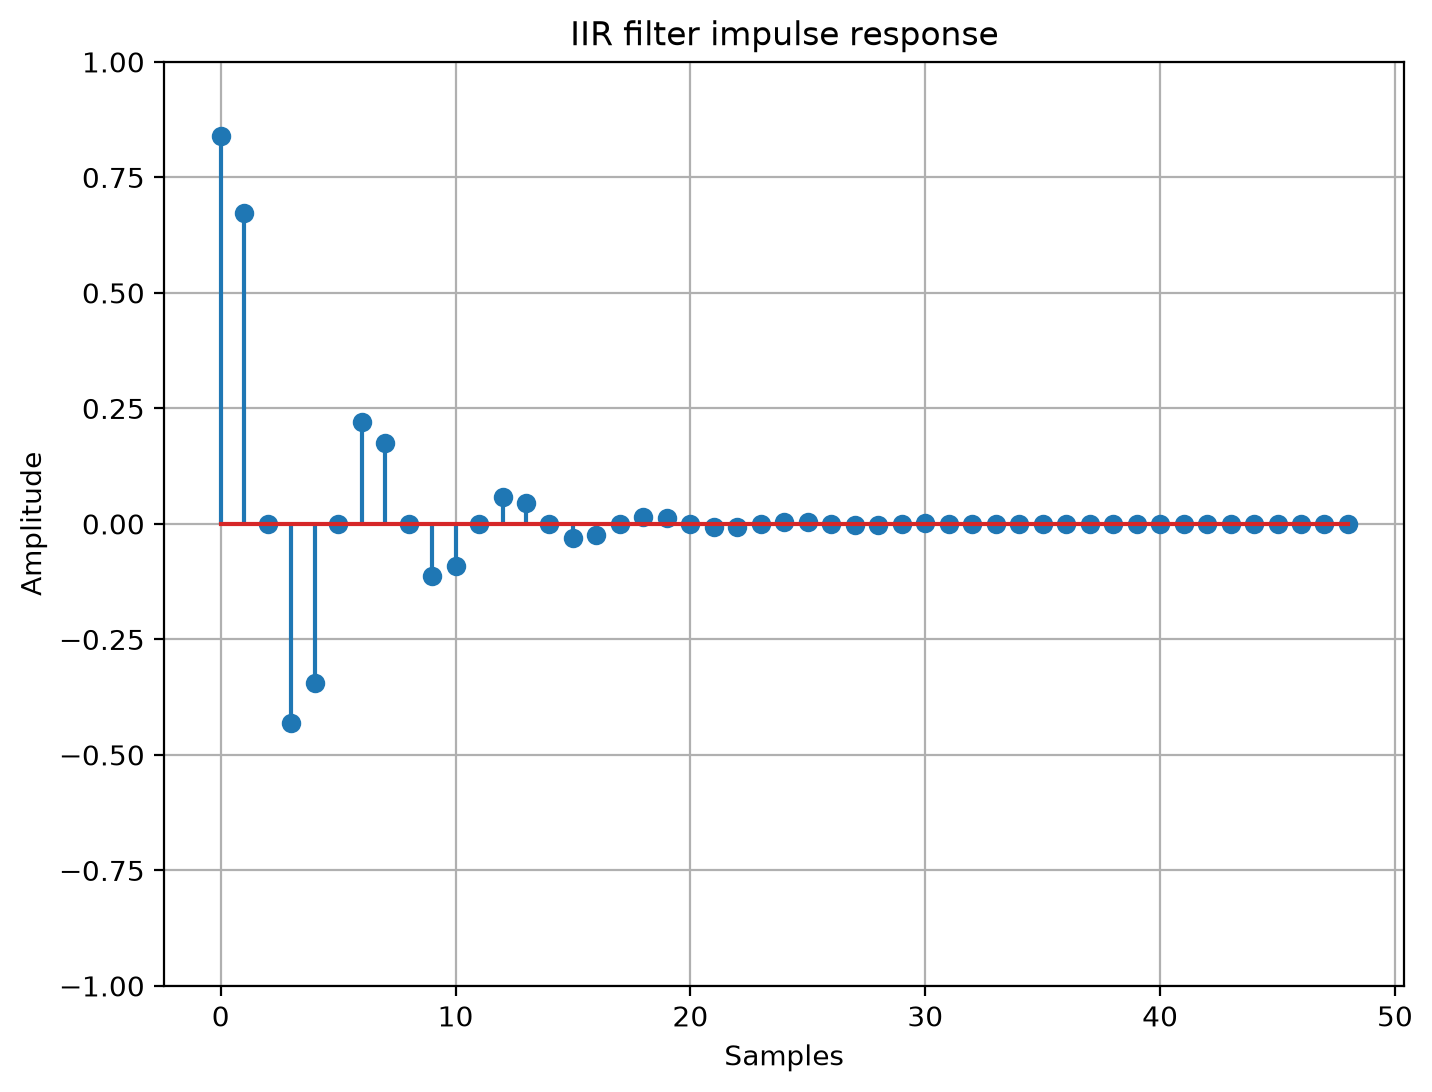

In [22]:
n_samples = 49
n = arange(n_samples)

filter_a1 = -0.8
filter_a2 = 0.64
filter_b0 = 0.84

b = [filter_b0]
a = [1, filter_a1, filter_a2]

# System input (Kronecker delta)
x = zeros(n_samples)
x[0] = 1

# System output (impulse response)
impulse_response_iir = lfilter(b, a, x)

# Manual implementation (alternative to lfilter)
# impulse_response_iir = zeros(n_samples)
# for k in range(n_samples):
#     impulse_response_iir[k] += filter_b0 * x[k]
#     if k >= 1:
#         impulse_response_iir[k] += -filter_a1 * impulse_response_iir[k - 1]
#     if k >= 2:
#         impulse_response_iir[k] += -filter_a2 * impulse_response_iir[k - 2]

figure(1, figsize=(8, 6), dpi=200)
stem(n, impulse_response_iir)
ylim((-ceil(max(impulse_response_iir)), ceil(max(impulse_response_iir))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter impulse response")
grid(True)
show()

## Ejercicio 4 (c)

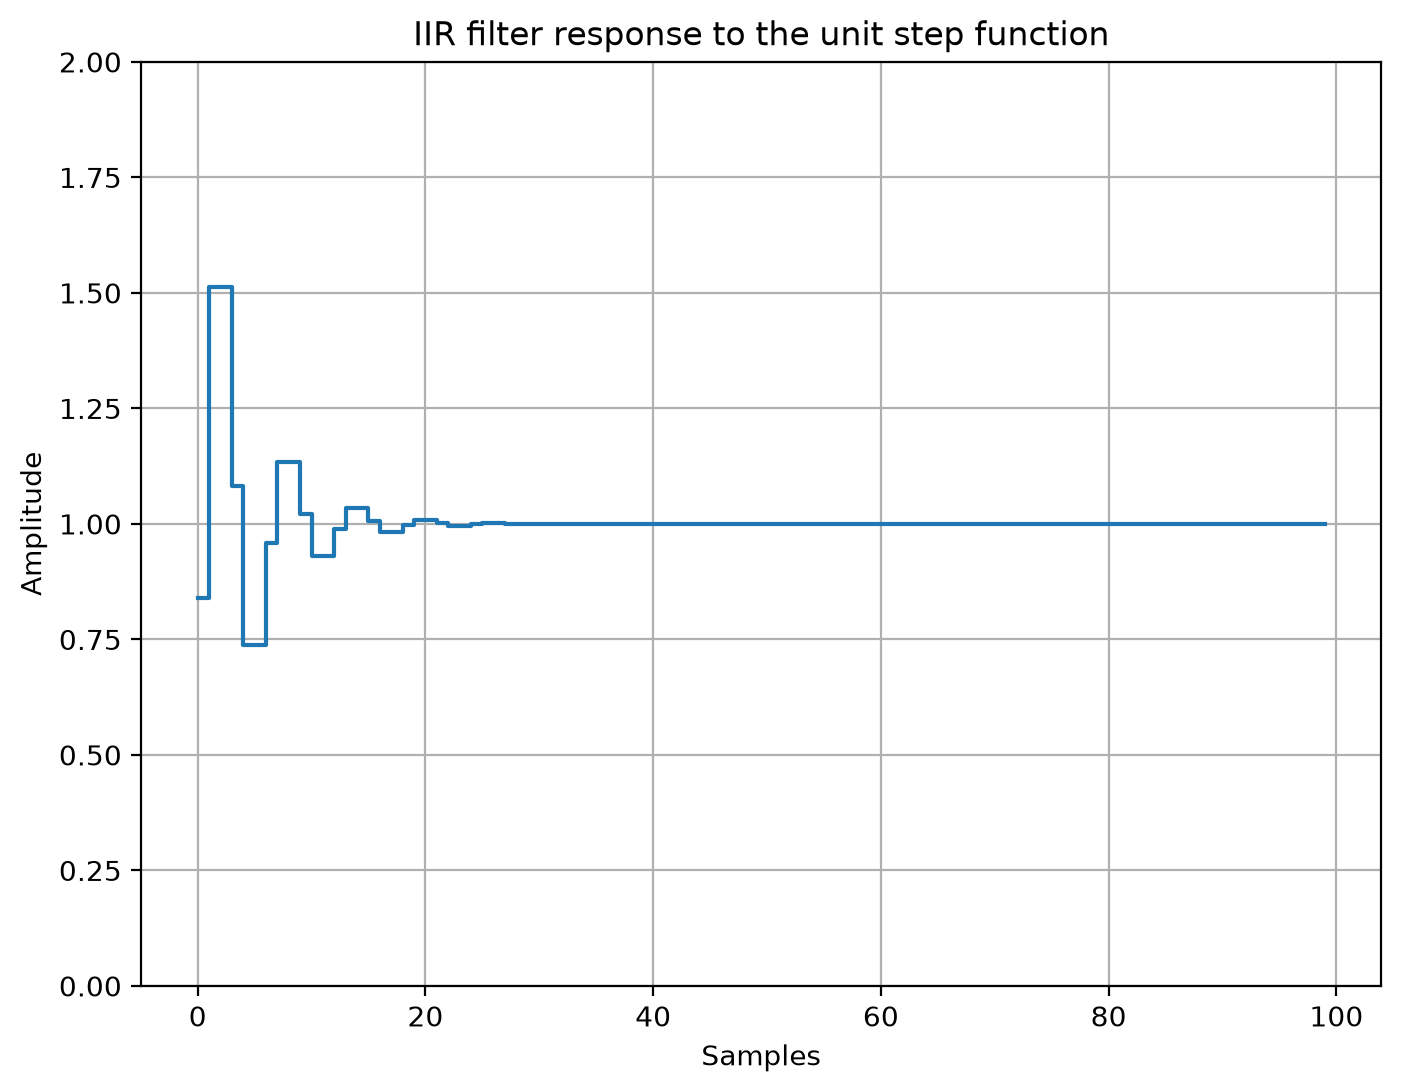

In [ ]:
n_samples = 100
n = arange(n_samples)

x = ones(n_samples)
y_1 = lfilter(b, a, x)

figure(1, figsize=(8, 6), dpi=200)
step(n, y_1, where="post")
ylim((0, ceil(max(y_1))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter response to the unit step function")
grid(True)
show()

## Ejercicio 4 (d)

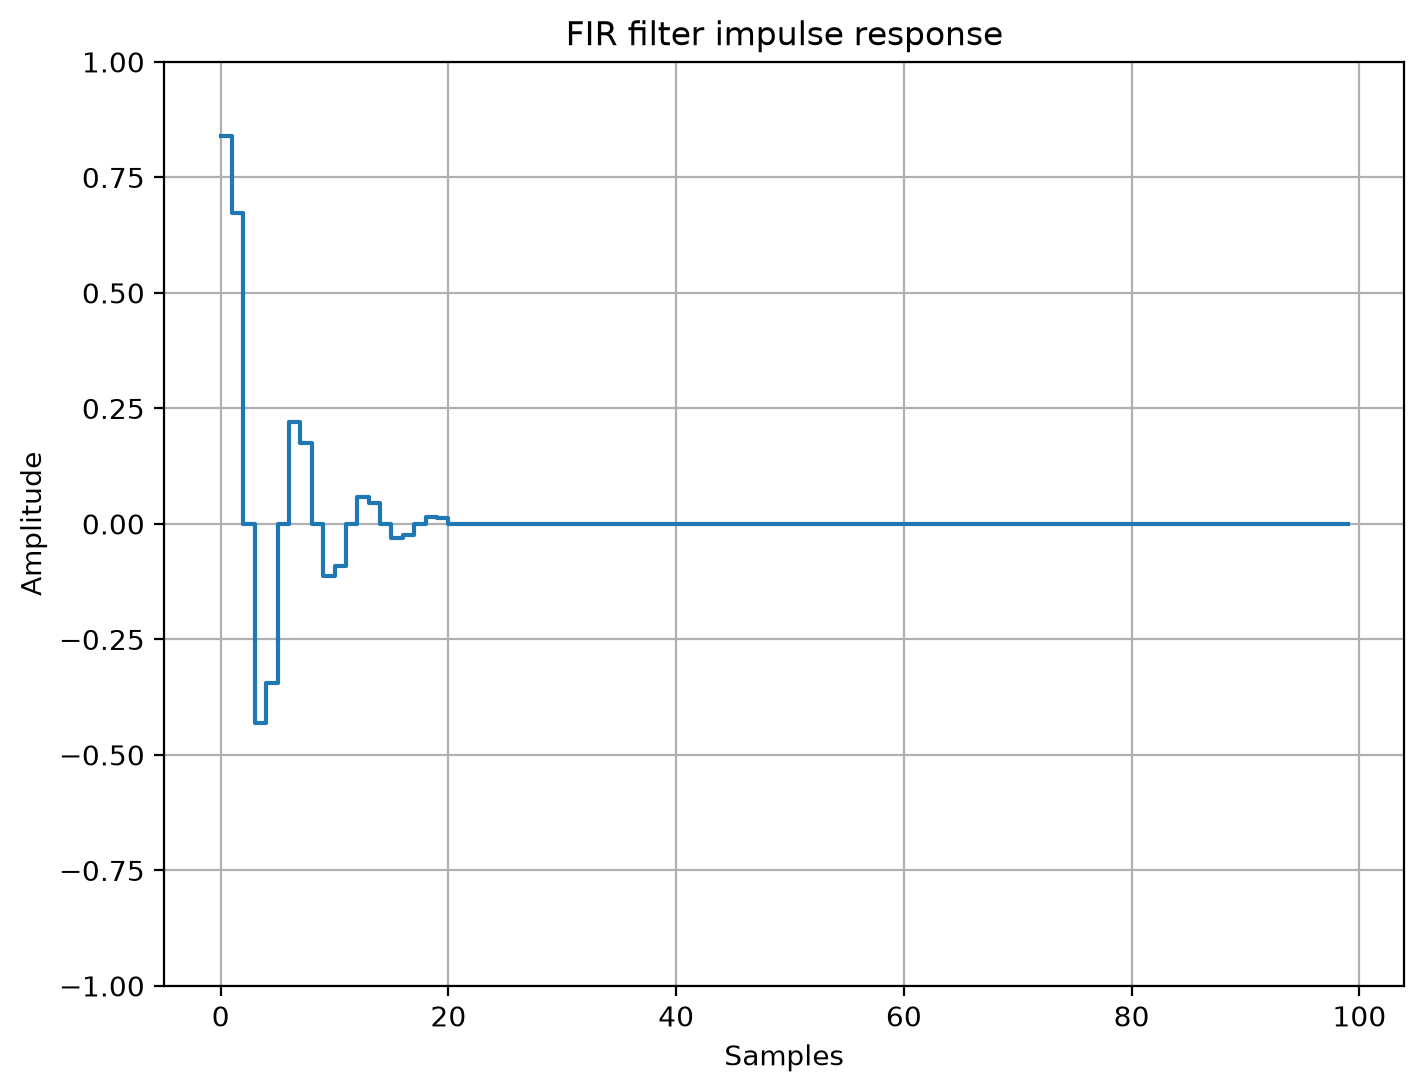

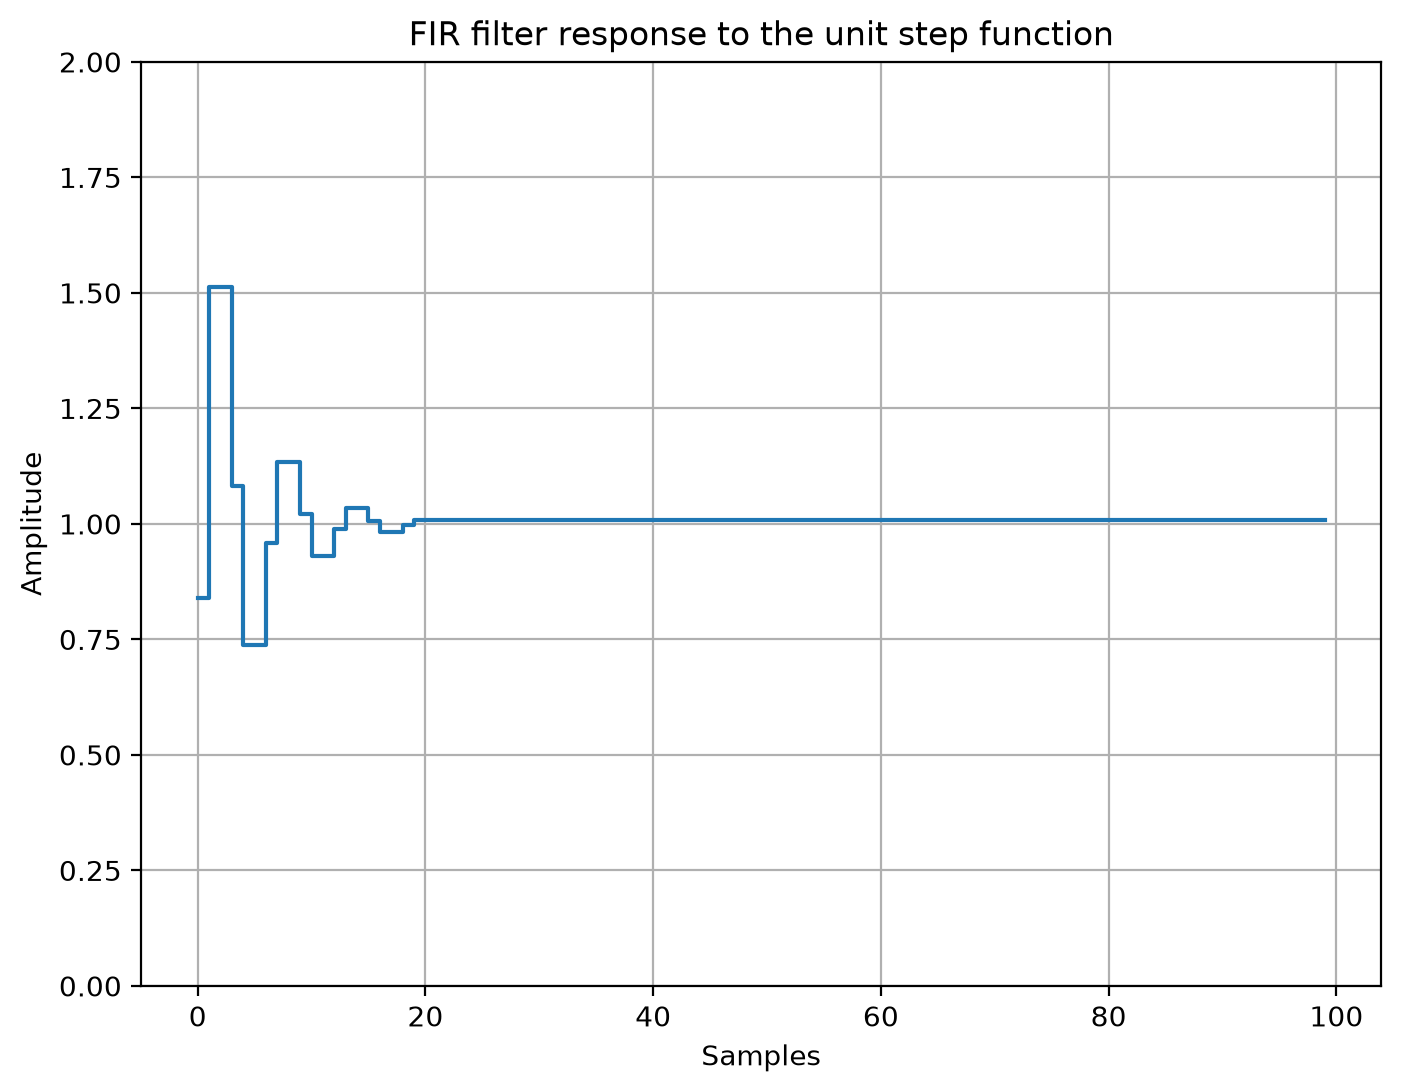

In [ ]:
n_samples = 100
n = arange(n_samples)

impulse_response_fir = zeros(n_samples)
impulse_response_fir[: 20 + 1] = impulse_response_iir[: 20 + 1]

x = ones(n_samples)
y_2 = convolve(x, impulse_response_fir)[:n_samples]

figure(1, figsize=(8, 6), dpi=200)
step(n, impulse_response_fir, where="post")
ylim((-ceil(max(impulse_response_fir)), ceil(max(impulse_response_fir))))
xlabel("Samples")
ylabel("Amplitude")
title("FIR filter impulse response")
grid(True)
show()

figure(1, figsize=(8, 6), dpi=200)
step(n, y_2, where="post")
ylim((0, ceil(max(y_2))))
xlabel("Samples")
ylabel("Amplitude")
title("FIR filter response to the unit step function")
grid(True)
show()

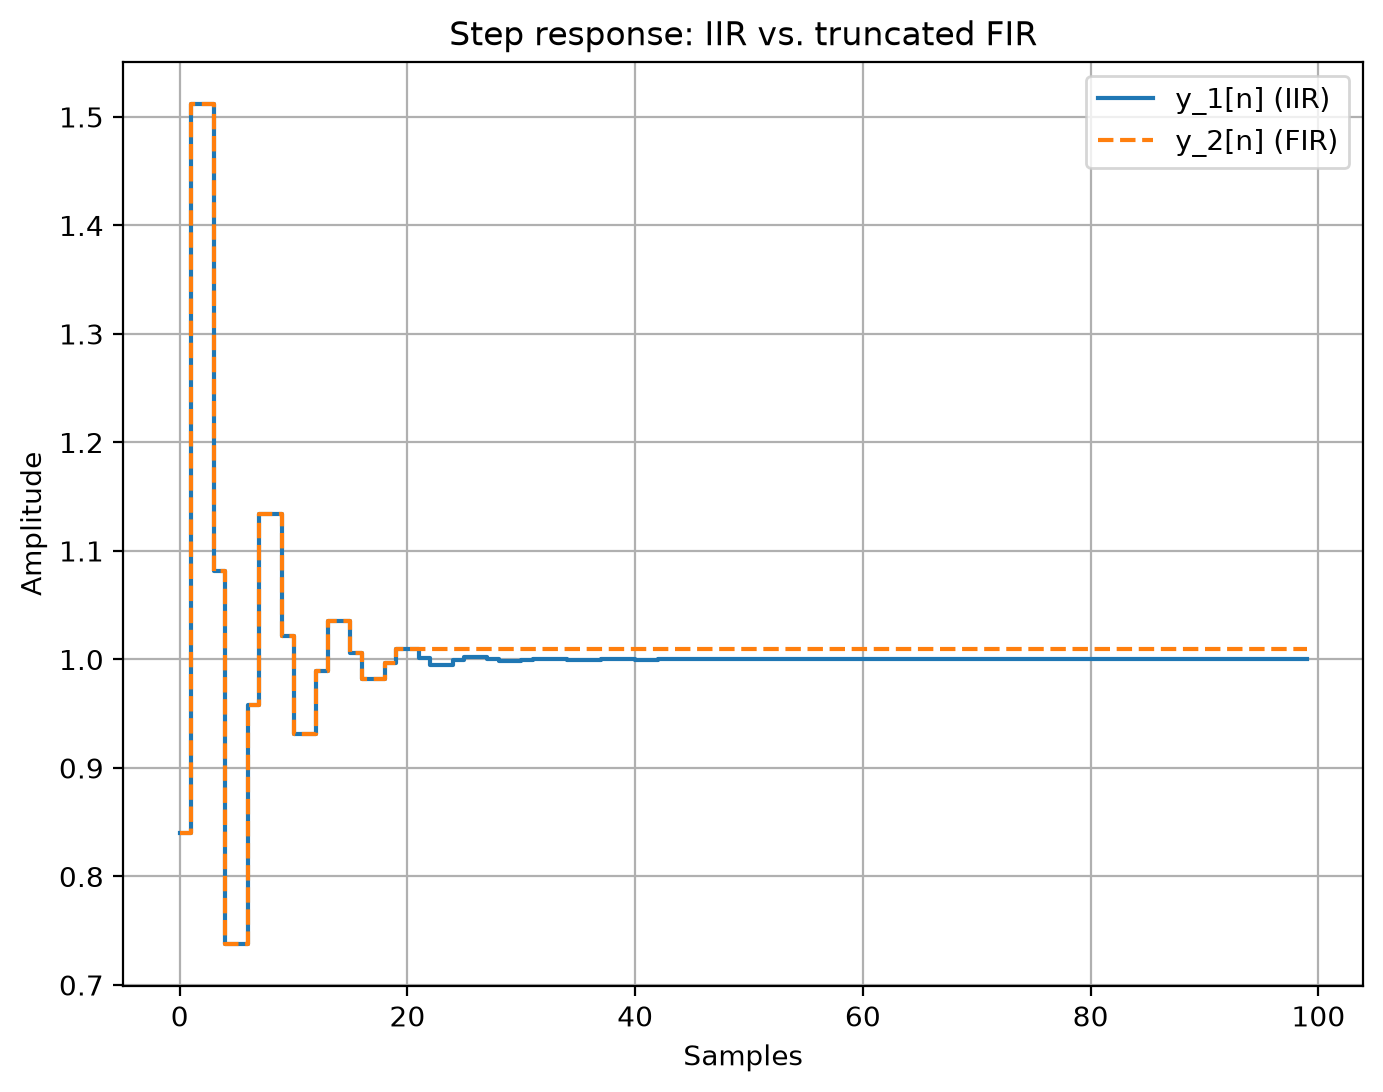

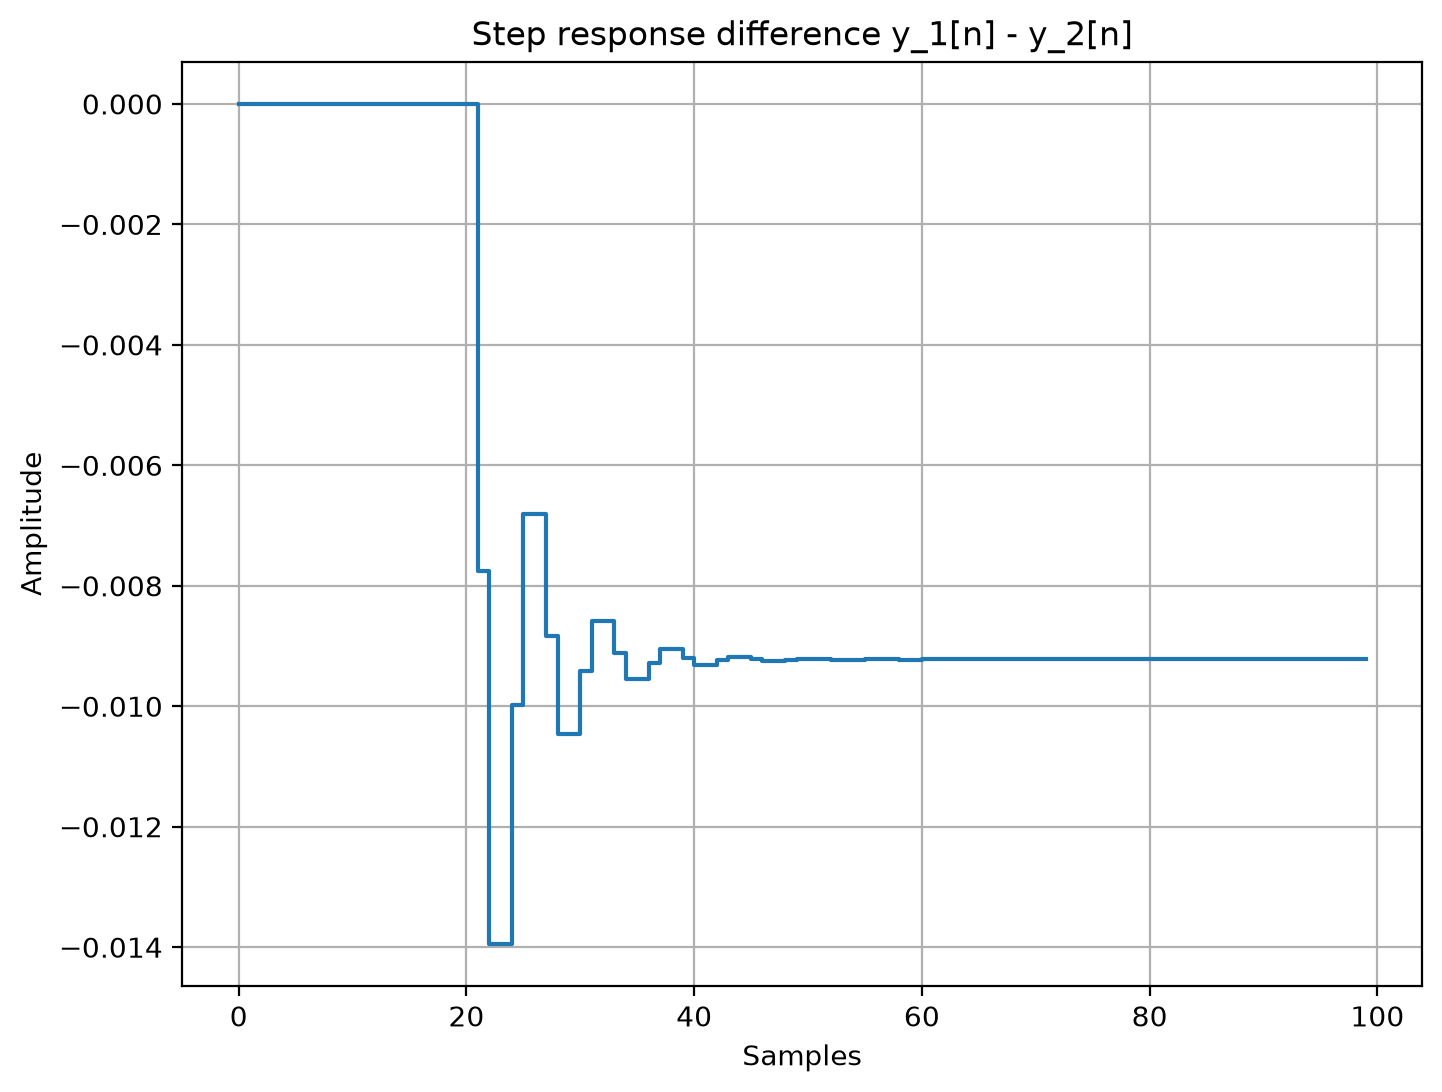

Max |y_1 - y_2| for n <= 20: 4.441e-16
Final value y_1: 1.000000
Final value y_2: 1.009223


In [25]:
figure(1, figsize=(8, 6), dpi=200)
step(n, y_1, where="post", label="y_1[n] (IIR)")
step(n, y_2, where="post", linestyle="--", label="y_2[n] (FIR)")
xlabel("Samples")
ylabel("Amplitude")
title("Step response: IIR vs. truncated FIR")
legend()
grid(True)
show()

figure(1, figsize=(8, 6), dpi=200)
step(n, y_1 - y_2, where="post")
xlabel("Samples")
ylabel("Amplitude")
title("Step response difference y_1[n] - y_2[n]")
grid(True)
show()

print(f"Max |y_1 - y_2| for n <= 20: {abs(y_1[:21] - y_2[:21]).max():.3e}")
print(f"Final value y_1: {y_1[-1]:.6f}")
print(f"Final value y_2: {y_2[-1]:.6f}")

Ambas respuestas coinciden exactamente para $0 \le n \le 20$: la respuesta al escalón es la suma acumulada de la respuesta impulsional, $y[n] = \sum_{k=0}^{n} h[k]$, y hasta $n = 20$ ambos filtros suman las mismas muestras.

A partir de $n = 21$ la salida del FIR queda constante en $\sum_{k=0}^{20} h[k] \approx 1{,}0092$, porque ya no hay más muestras de $h_{FIR}[n]$ para acumular. La del IIR, en cambio, sigue sumando la cola de $h[n]$ y converge a $H^f(0) = b_0 / (1 + a_1 + a_2) = 1$.

## Ejercicio 4 (e)

Transformando la ecuación en diferencias con la TFTD se obtiene la siguiente expresión para la respuesta en frecuencia del sistema:

$$
Y^f(\theta) (1+ a_1 e^{-j\theta} + a_2 e^{-j2\theta}) = b_0 X^f(\theta)
$$

$$
H^f(\theta) = \frac{b_0}{1 + a_1 e^{-j\theta} + a_2 e^{-j2\theta}}
$$

Graficando módulo y fase de esta respuesta se puede determinar fácilmente que se trata de un filtro pasabanda con un pico en la banda de paso en $\pi/3$.

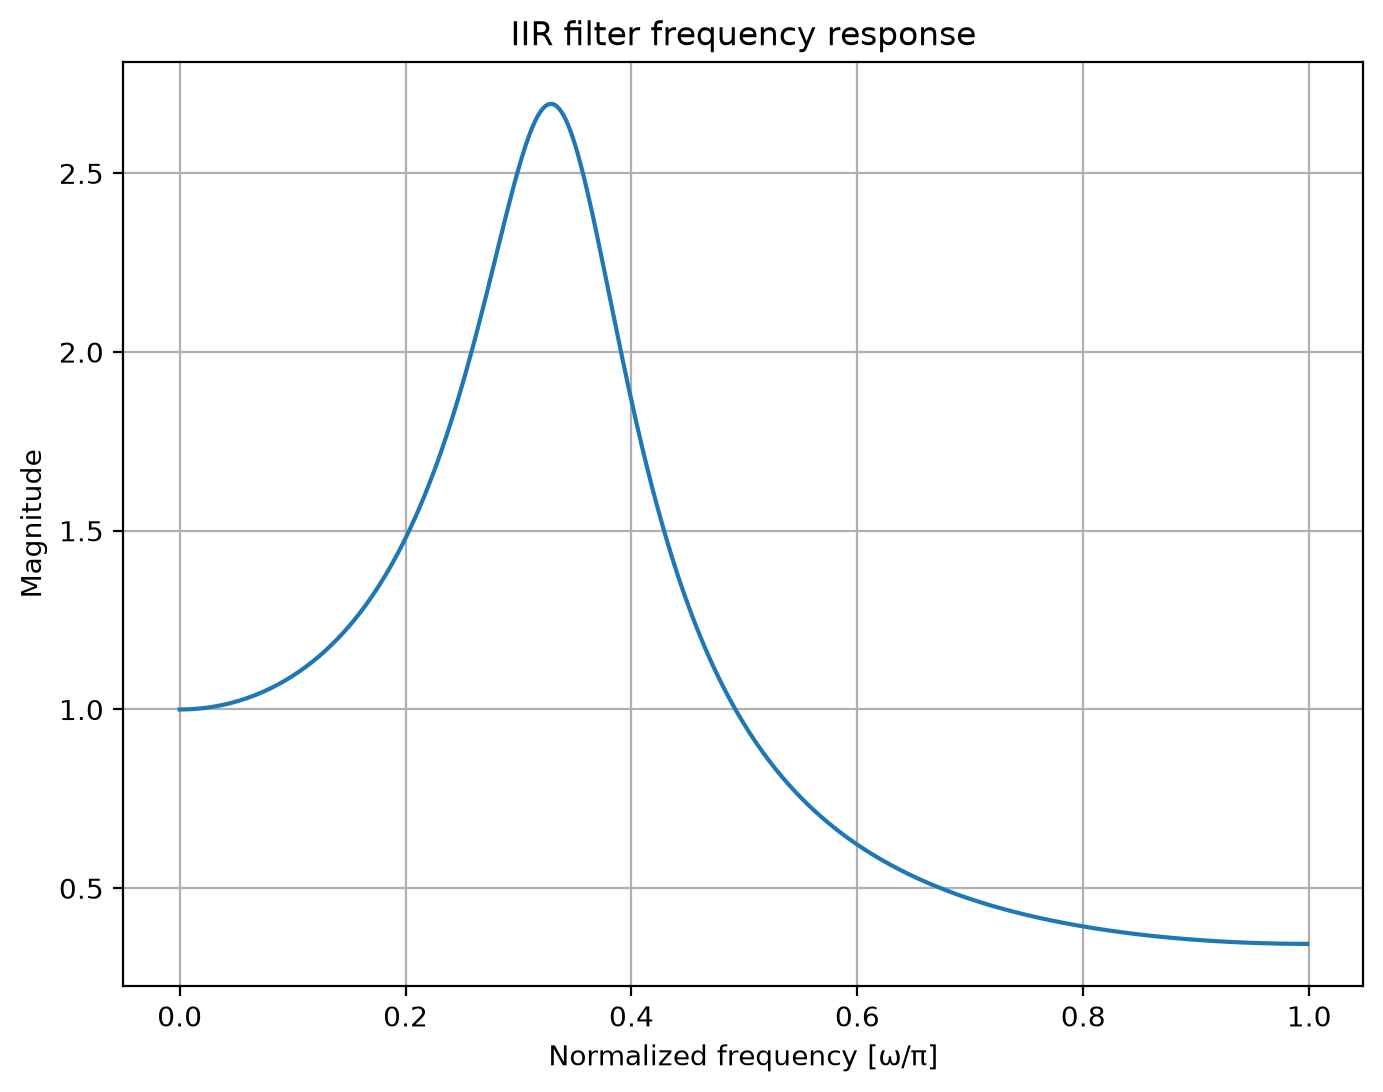

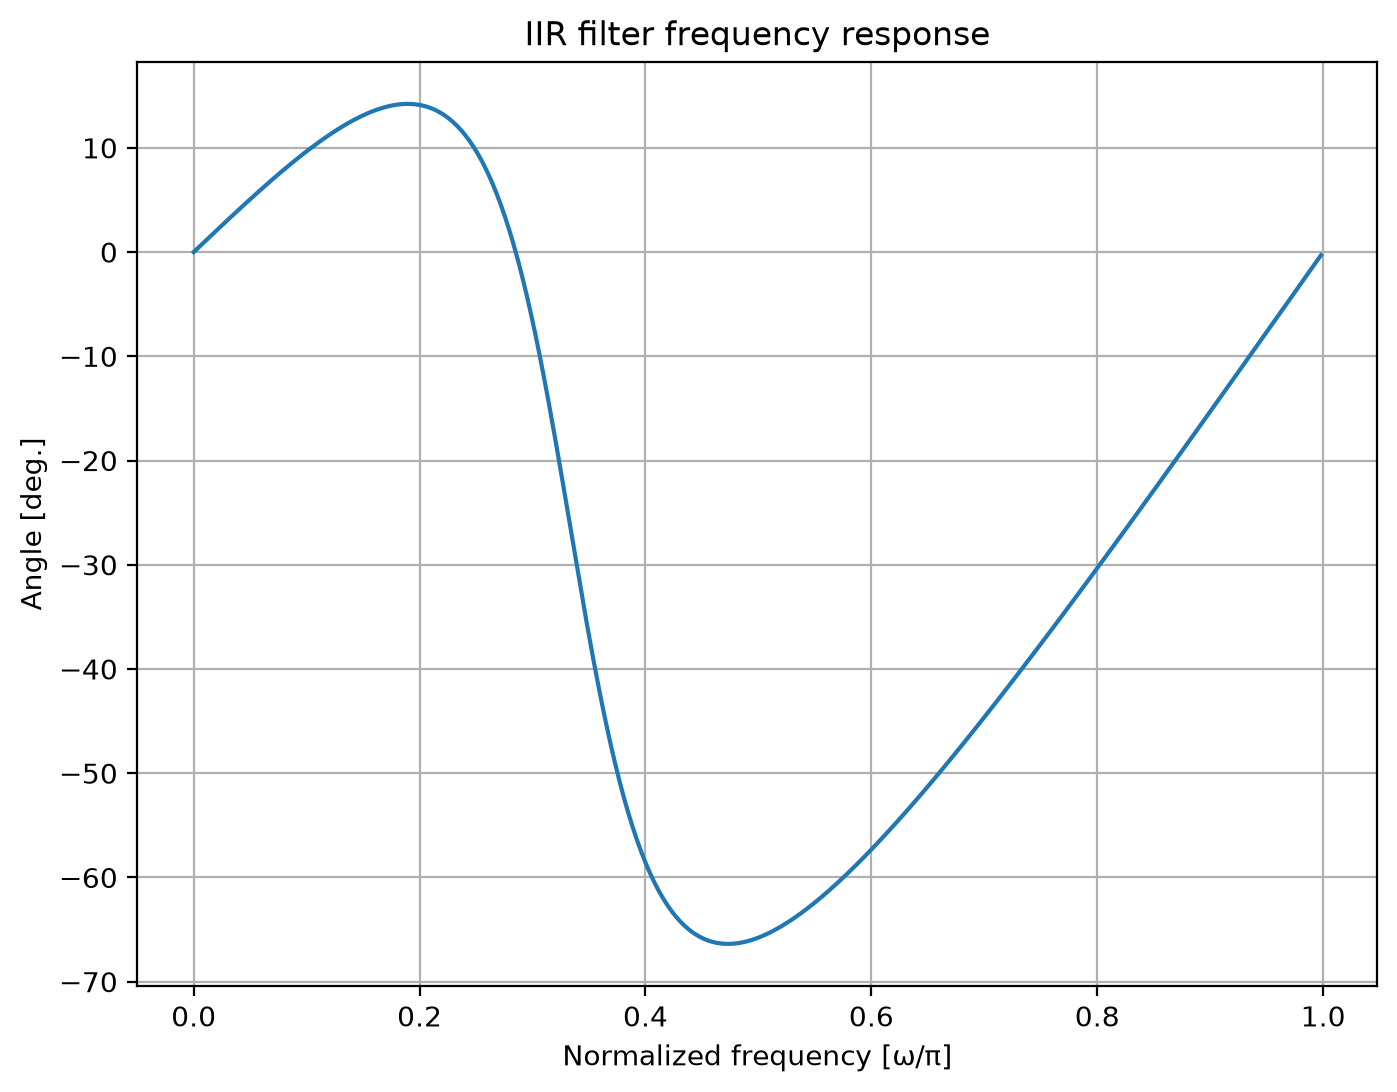

In [26]:
w, H = freqz(b, a)

figure(1, figsize=(8, 6), dpi=200)
plot(w / pi, abs(H))
xlabel("Normalized frequency [ω/π]")
ylabel("Magnitude")
title("IIR filter frequency response")
grid(True)
show()

figure(1, figsize=(8, 6), dpi=200)
plot(w / pi, unwrap(angle(H)) * 180 / pi)
xlabel("Normalized frequency [ω/π]")
ylabel("Angle [deg.]")
title("IIR filter frequency response")
grid(True)
show()

## Ejercicio 4 (f)

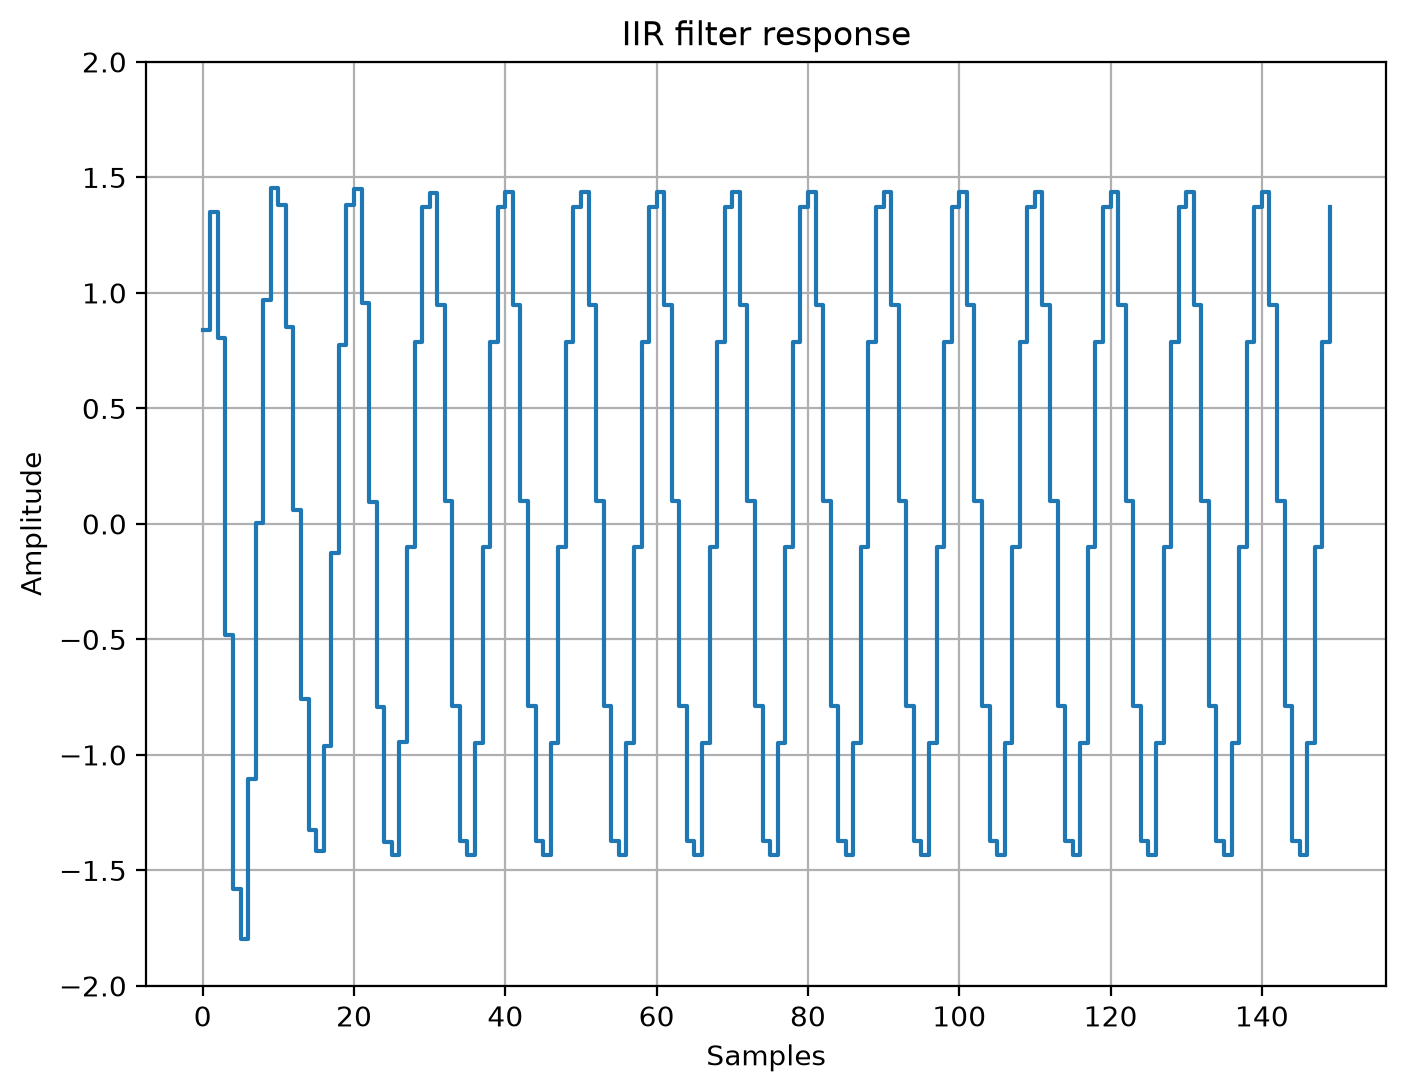

In [27]:
n_samples = 150
n = arange(n_samples)

x = cos(2 * pi * n / 10)
y = convolve(x, impulse_response_iir)[:n_samples]

figure(1, figsize=(8, 6), dpi=200)
step(n, y, where="post")
ylim((-ceil(max(y)), ceil(max(y))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter response")
grid(True)
show()